In [ ]:
import os, sys, importlib

sys.path.append(('./../'))
from toolbox import npv0_utils as utils, npv0_cfc as cfc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import ticker
import seaborn as sns

treat_map = {'control': plt.cm.viridis(np.linspace(0.4,0.6,1)), 
             'muscimol': plt.cm.magma(np.linspace(0.4,0.6,1))}
voc_map = {'vocal': plt.cm.Spectral(np.linspace(0.12,0.2,1)), 
           'non-vocal': plt.cm.Spectral(np.linspace(0.86,0.95,1))}

def _despine(ax):
    ax.spines[['right', 'top']].set_visible(False)

# results_dir = './'


In [ ]:
data_dir = './../../data/neural_data/LFP_parallel'
data = utils.load_cache_data(data_dir)

#### Plot CFC results for individual animals

In [4]:
Fs = 10e3
phase_bands = cfc.make_phase_bands(start=1, stop=8, step=1, width=2)
amp_bands   = cfc.make_amp_bands(start=15, stop=120, step=5, width=10)
phase_centers = (phase_bands[0] + 1).astype(int)
amp_centers = (amp_bands[0] + 5).astype(int)

treats = ['control','muscimol']
voc_periods = ['vocal','non-vocal']

##### Mutual Information over entire recording

M3
M4
F4
F3


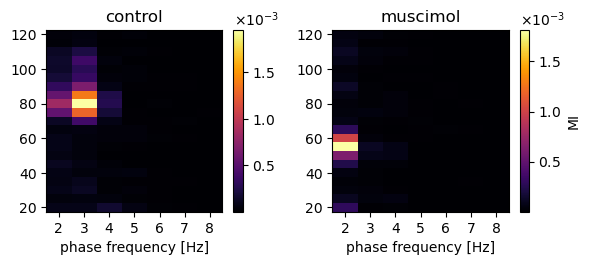

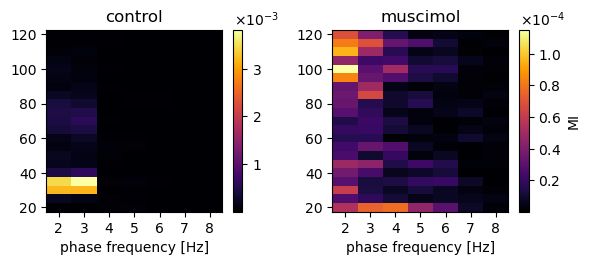

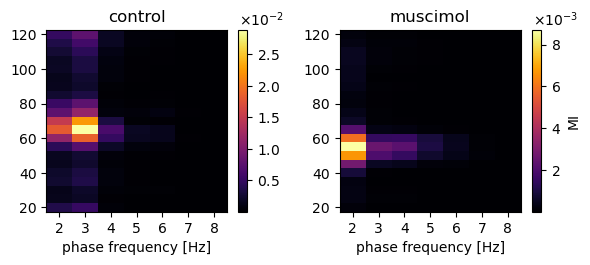

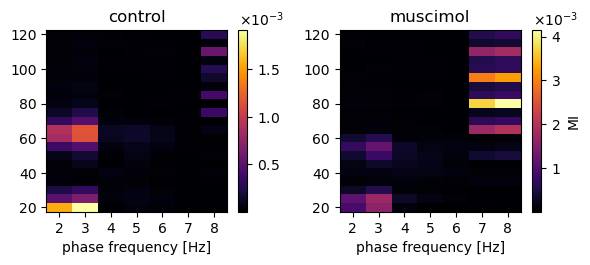

In [45]:
grouping = 'all'
for anim in data.keys():
    print(anim)

    sharedcb = False
    if sharedcb: w=5
    else: w=6
        
    fig, axes = plt.subplots(1,2, figsize=(w,3))
    pcms = [] # colormaps
    for i, treat in enumerate(treats): # control, muscimol
        plt_data = data[anim]['lfp_data'][treat][grouping]['MI_mat']


        _, ax, pcm = cfc.plot_comodulogram(plt_data, phase_bands, amp_bands,                                 
                                colorbar=(not sharedcb),
                                cb_label=None if i == 0 else 'MI',
                                cb_powerlimits=(0,0),
                                cb_x_lab=0.09,
                                title=treat,
                                ax=axes[i])
        ax.set_xticks(phase_centers)
        ax.set_xticklabels(phase_centers)
        pcms.append(pcm)

        if sharedcb:  
            shared = '_sharedcolorbar'     
            cbax = fig.add_axes([1.025, 0.25, 0.015, 0.4])  
            cfc.shared_colorbar(fig, pcms, cax=cbax, label='MI', cb_x_lab=0.09)
            axes[i].label_outer()
        else:
            shared = '_indcolorbar'
            axes[i].set_ylabel('')
        fig.tight_layout()
        fig.subplots_adjust(wspace=0.3, top=0.8)

        for ext in ['png','pdf']:
            fig.savefig(results_dir+'/'+anim+'_MI_'+treat+'_'+grouping+shared+'.'+ext, 
                    bbox_inches='tight', transparent=True, dpi=500)


##### Mutual Information in vocal/non-vocal periods (equal N)

M3
M4
F4
F3


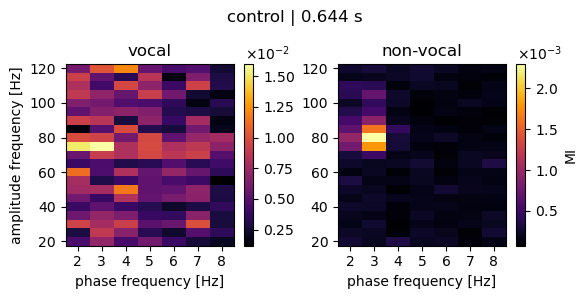

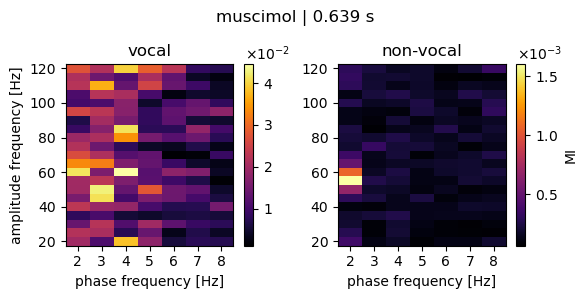

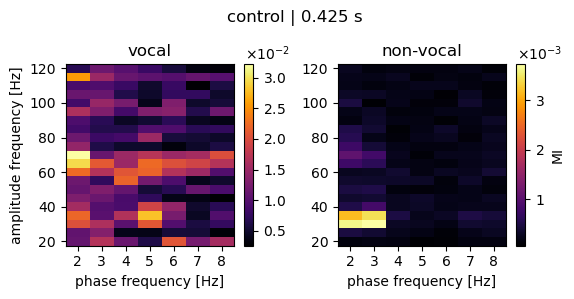

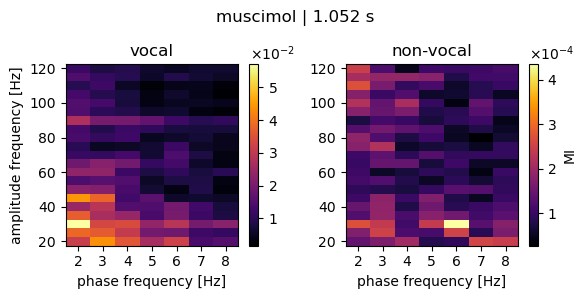

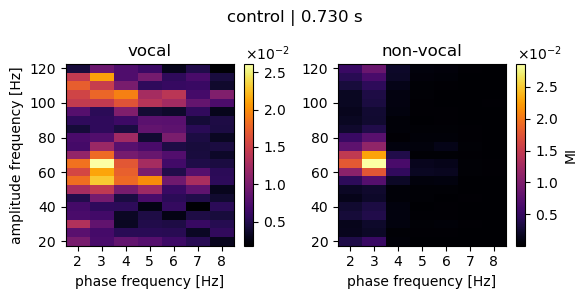

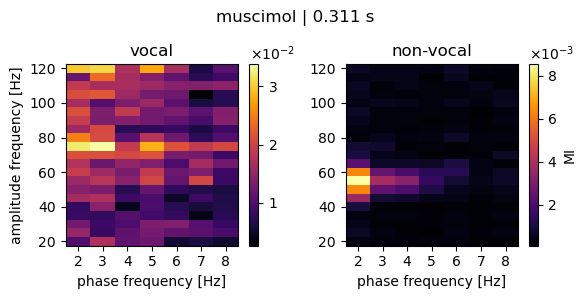

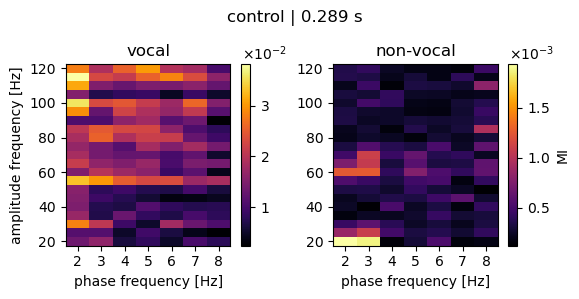

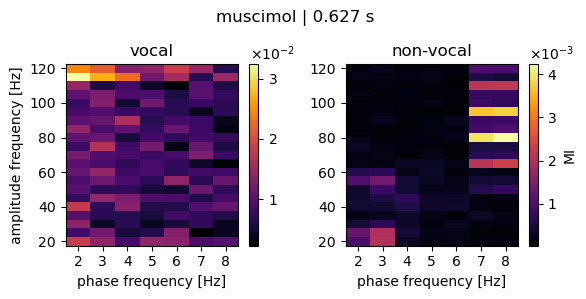

In [ ]:
grouping = 'within'
importlib.reload(cfc)
for anim in ['F4']: #data.keys():
    print(anim)

    sharedcb = False
    if sharedcb: w=5
    else: w=6
        
    for treat in treats: # control, muscimol
        plt_data = data[anim]['lfp_data'][treat][grouping]['MI_mat']

        fig, axes = plt.subplots(1,2, figsize=(w,3))
        pcms = [] # colormaps
        for i, period in enumerate(plt_data.keys()): # vocal, non-vocal
            len_data = data[anim]['lfp_data'][treat][grouping]['n']
            _, ax, pcm = cfc.plot_comodulogram(plt_data[period], phase_bands, amp_bands,                                 
                                colorbar=(not sharedcb),
                                cb_label=None if i == 0 else 'MI',
                                cb_powerlimits=(0,0),
                                cb_x_lab=0.09,
                                title=period,
                                ax=axes[i])
            ax.set_xticks(phase_centers)
            ax.set_xticklabels(phase_centers)
            pcms.append(pcm)

        if sharedcb:  
            shared = '_sharedcolorbar'     
            cbax = fig.add_axes([1.025, 0.25, 0.015, 0.4])  
            cfc.shared_colorbar(fig, pcms, cax=cbax, label='MI', cb_x_lab=0.09)
            axes[i].label_outer()
        else:
            shared = '_indcolorbar'
            axes[i].set_ylabel('')
        fig.suptitle(f'{treat} | {len_data/Fs:,.3f} s')
        fig.tight_layout()
        fig.subplots_adjust(wspace=0.3, top=0.8)

        # for ext in ['png','pdf']:
        #     fig.savefig(results_dir+'/'+anim+'_MI_'+treat+'_'+grouping+shared+'.'+ext, 
        #             bbox_inches='tight', transparent=True, dpi=500)


In [5]:
      
def get_peak_MI_freqs(MI_mat, phase_bands, amp_bands):
    """
    MI_mat is a dict of dicts: MI_mat[phase_band][amp_band] = {'mi': value, 'p': value}
    phase_bands and amp_bands are lists of tuples: [(low1, high1), (low2, high2), ...]
    """
    matrix = np.array([[MI_mat[fpha][fAmp]['mi'] for fAmp in MI_mat[fpha]] for fpha in MI_mat])
    peak_MI = np.max(matrix)
    peak_idx = np.unravel_index(np.argmax(matrix), matrix.shape)
    peak_freqs_lo = (phase_bands[0][peak_idx[0]], amp_bands[0][peak_idx[1]])
    peak_freqs_center = (phase_bands[0][peak_idx[0]]+1, amp_bands[0][peak_idx[1]]+5)

    return peak_freqs_lo, peak_freqs_center, peak_MI, peak_idx

Mutual information values are more sharply tuned to a particular phase-amplitude
frequency pair in steady-state/non-vocal contexts. During vocalization, we observe
higher mutual information across a broader range of frequencies pairings, with less
frequency-specific coupling. 

Generalization: 
- Showing standard deviation of MI values for vocal/non-vocal, control/muscimol
for each animal. Check. 

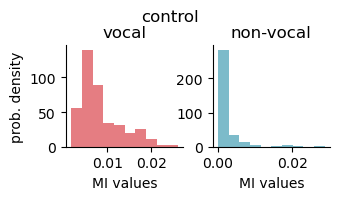

In [9]:
anim = 'F4'
treat = 'control'
fig, axes = plt.subplots(1,2, figsize=(3.5,2))
for i, period in enumerate(['vocal','non-vocal']):
    MI_data = data[anim]['lfp_data'][treat]['within']['MI_mat'][period]
    matrix = np.array([[MI_data[fpha][fAmp]['mi'] for fAmp in MI_data[fpha]] for fpha in MI_data])
    axes[i].hist(np.concatenate(matrix), color=voc_map[period], bins=10, alpha=0.7, label=period, density=True)
    axes[i].set_xlabel('MI values')
    axes[0].set_ylabel('prob. density')
    axes[i].set_title(period)
    # axes[i].legend(loc='upper right',bbox_to_anchor=(1, 1), frameon=False)
    _despine(axes[i])
fig.suptitle(treat)
fig.tight_layout()
fig.subplots_adjust(wspace=0.25, top=0.8)
for ext in ['png','pdf']:
    fig.savefig(results_dir+'/'+anim+'_MI_'+treat+'_MIdist.'+ext, 
            bbox_inches='tight', transparent=True, dpi=500)

Amplitudes of preferred gamma frequencies may show similar phase preference in preferred
delta frequencies. 

For F4, muscimol have different frequency preferences, and the preferred phase is 
shifted by a half cycle

(2, 60)
(2, 60)


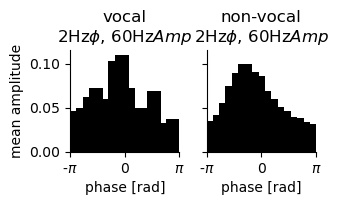

In [48]:
anim = 'F4'
treat = 'control'
shift = False
fig, axes = plt.subplots(1,2, figsize=(3.5,2), sharey=True)
for i, period in enumerate(['vocal','non-vocal']):
    MI_data = data[anim]['lfp_data'][treat]['within']['MI_mat'][period]
    fpeak,_,_,_ = get_peak_MI_freqs(MI_data, phase_bands, amp_bands)
    print(fpeak)
    amp_vals = MI_data[fpeak[0]][fpeak[1]]['p'] # lower edges: 2->3, 60->65
    if shift: 
        amp_vals = np.roll(amp_vals, 9) 
        print('Actually shifted! x-axis wrong')
    pha_vals = np.linspace(-np.pi, np.pi, len(amp_vals))
    axes[i].bar(pha_vals, amp_vals, facecolor='k')
    axes[i].set_xlim(-np.pi, np.pi)
    axes[i].set_xticks([-np.pi, 0, np.pi])
    axes[i].set_xticklabels(['-$\pi$', 0, '$\pi$'])
    axes[i].set_xlabel('phase [rad]')
    axes[0].set_ylabel('mean amplitude')
    axes[i].set_title(f'{period}\n{fpeak[0]}Hz$\phi$, {fpeak[1]}Hz$Amp$')
    _despine(axes[i])
fig.tight_layout()
fig.subplots_adjust(wspace=0.25, top=0.8)
for ext in ['png','pdf']:
    fig.savefig(results_dir+'/'+anim+'_MI_'+treat+'_ampdistpeak.'+ext, 
            bbox_inches='tight', transparent=True, dpi=500)

In [274]:
def set_cb_ticks(cb, pcm, n=3):
    vmin, vmax = pcm.get_clim()
    ticks = np.linspace(vmin, vmax, n)
    cb.set_ticks(ticks)
    cb.set_ticklabels([f'{t:.2f}' for t in ticks])

For vocal and non-vocal periods, the peak gamma frequency may show phase coherence
over multiple delta frequencies

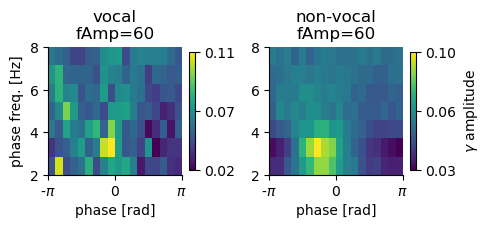

In [331]:
anim = 'F4'
treat = 'control'
shift = False
fig, axes = plt.subplots(1,2, figsize=(5,3))
pcms = [] # colormaps
for i, period in enumerate(['vocal','non-vocal']):
    MI_data = data[anim]['lfp_data'][treat]['within']['MI_mat'][period]
    fpeak,_,_,fpeak_idx = get_peak_MI_freqs(MI_data, phase_bands, amp_bands)
    matrix = np.array([[MI_data[fpha][fAmp]['p'] for fAmp in MI_data[fpha]] for fpha in MI_data])
    Amp_over_phases = matrix[:,fpeak_idx[1],:]
    if shift:
        Amp_over_phases = np.roll(Amp_over_phases, 9)
    pcm = axes[i].imshow(Amp_over_phases, extent=[-np.pi, np.pi, 2, 8], origin='lower', aspect='equal')
    pcms.append(pcm)
    cb = fig.colorbar(pcm, ax=axes[i], label='', fraction=0.04)
    set_cb_ticks(cb, pcm, n=3)  # or n=2 for just min/max
    axes[i].set_xlim(-np.pi, np.pi)
    axes[i].set_xticks([-np.pi, 0, np.pi])
    axes[i].set_xticklabels(['-$\pi$', 0, '$\pi$'])
    axes[i].set_xlabel('phase [rad]')
    axes[0].set_ylabel('phase freq. [Hz]')
    axes[i].set_title(f'{period}\nfAmp={fpeak[1]}')
    _despine(axes[i])
cb.set_label('$\gamma$ amplitude')
fig.tight_layout()
# fig.subplots_adjust(wspace=0.3, top=0.8)

##### Mutual Information in control/muscimol for vocal periods (equal N)

F4


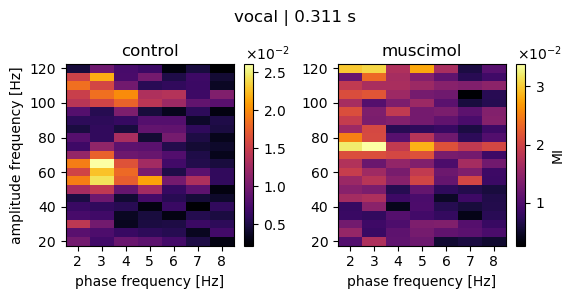

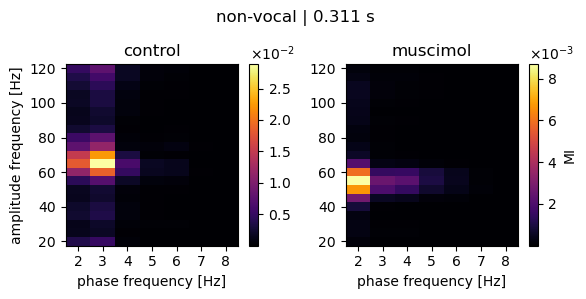

In [8]:
grouping = 'across'
for anim in ['F4']: #data.keys():
    print(anim)

    sharedcb = False
    if sharedcb: w=5
    else: w=6
        
    for period in voc_periods: # vocal, non-vocal

        fig, axes = plt.subplots(1,2, figsize=(w,3))
        pcms = [] # colormaps
        for i, treat in enumerate(treats): # control, muscimol
            plt_data = data[anim]['lfp_data'][treat][grouping]['MI_mat']
            len_data = data[anim]['lfp_data'][treat][grouping]['n']
            if grouping == 'across':
                len_data = len_data['vocal']

            _, ax, pcm = cfc.plot_comodulogram(plt_data[period], phase_bands, amp_bands, 
                                
                                colorbar=(not sharedcb),
                                cb_label=None if i == 0 else 'MI',
                                cb_powerlimits=(0,0),
                                cb_x_lab=0.09,
                                title=treat,
                                ax=axes[i])
            ax.set_xticks(phase_centers)
            ax.set_xticklabels(phase_centers)
            pcms.append(pcm)

        if sharedcb:  
            shared = '_sharedcolorbar'     
            cbax = fig.add_axes([1.025, 0.25, 0.015, 0.4])  
            cfc.shared_colorbar(fig, pcms, cax=cbax, label='MI', cb_x_lab=0.09)
            axes[i].label_outer()
        else:
            shared = '_indcolorbar'
            axes[i].set_ylabel('')
        fig.suptitle(f'{period} | {len_data/Fs:,.3f} s')
        fig.tight_layout()
        fig.subplots_adjust(wspace=0.3, top=0.8)

        # for ext in ['png','pdf']:
        #     fig.savefig(results_dir+'/'+anim+'_MI_'+period+'_'+grouping+shared+'.'+ext, 
        #             bbox_inches='tight', transparent=True, dpi=500)


Spread of MIs between control and muscimol?

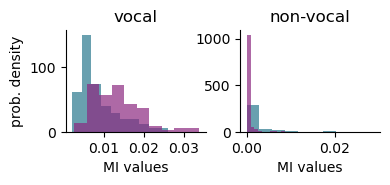

In [398]:
anim = 'F4'
# period = 'vocal'
fig, axes = plt.subplots(1,2, figsize=(4,2), sharey=False)

for i, treat in enumerate(treats):
    for j, period in enumerate(['vocal','non-vocal']):
        ax = axes[j]
        MI_data = data[anim]['lfp_data'][treat]['across']['MI_mat'][period]
        matrix = np.array([[MI_data[fpha][fAmp]['mi'] for fAmp in MI_data[fpha]] for fpha in MI_data])
        ax.hist(np.concatenate(matrix), color=treat_map[treat], bins=10, alpha=0.7, label=treat, density=True)
        ax.set_xlabel('MI values')
        axes[0].set_ylabel('prob. density')
        ax.set_title(period)
        axes[0]._remove_legend
        _despine(ax)
# fig.legend()
fig.tight_layout()
fig.subplots_adjust(wspace=0.25, top=0.8)

Are these equally phase coherent between control and muscimol?

(2, 60)
(2, 70)


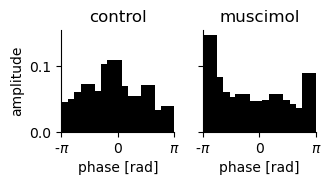

In [333]:
anim = 'F4'
period = 'vocal'
shift = False
fig, axes = plt.subplots(1,2, figsize=(3.5,2), sharey=True)
for i, treat in enumerate(treats):
    MI_data = data[anim]['lfp_data'][treat]['across']['MI_mat'][period]
    fpeak,_,_,_ = get_peak_MI_freqs(MI_data, phase_bands, amp_bands)
    print(fpeak)
    amp_vals = data[anim]['lfp_data'][treat]['across']['MI_mat'][period][fpeak[0]][fpeak[1]]['p'] # lower edges: 2->3, 60->65
    if shift: 
        amp_vals = np.roll(amp_vals, 9) 
        print('Actually shifted! x-axis wrong')
    pha_vals = np.linspace(-np.pi, np.pi, len(amp_vals))
    axes[i].bar(pha_vals, amp_vals, facecolor='k')
    axes[i].set_xlim(-np.pi, np.pi)
    axes[i].set_xticks([-np.pi, 0, np.pi])
    axes[i].set_xticklabels(['-$\pi$', 0, '$\pi$'])
    axes[i].set_xlabel('phase [rad]')
    axes[0].set_ylabel('amplitude')
    axes[i].set_title(treat)
    _despine(axes[i])
fig.tight_layout()
fig.subplots_adjust(wspace=0.25, top=0.8)

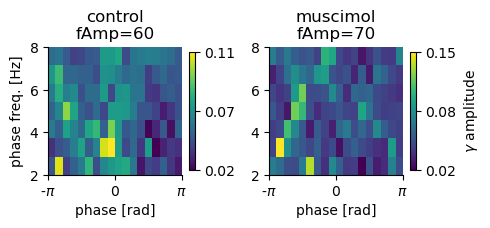

In [400]:
anim = 'F4'
period = 'vocal'
shift = False
fig, axes = plt.subplots(1,2, figsize=(5,3))
pcms = [] # colormaps
for i, treat in enumerate(treats):
    MI_data = data[anim]['lfp_data'][treat]['across']['MI_mat'][period]
    fpeak,_,_,fpeak_idx = get_peak_MI_freqs(MI_data, phase_bands, amp_bands)
    matrix = np.array([[MI_data[fpha][fAmp]['p'] for fAmp in MI_data[fpha]] for fpha in MI_data])
    Amp_over_phases = matrix[:,fpeak_idx[1],:]
    if shift:
        Amp_over_phases = np.roll(Amp_over_phases, 9)
    pcm = axes[i].imshow(Amp_over_phases, extent=[-np.pi, np.pi, 2, 8], origin='lower', aspect='equal')
    pcms.append(pcm)
    cb = fig.colorbar(pcm, ax=axes[i], label='', fraction=0.04)
    set_cb_ticks(cb, pcm, n=3)  # or n=2 for just min/max
    axes[i].set_xlim(-np.pi, np.pi)
    axes[i].set_xticks([-np.pi, 0, np.pi])
    axes[i].set_xticklabels(['-$\pi$', 0, '$\pi$'])
    axes[i].set_xlabel('phase [rad]')
    axes[0].set_ylabel('phase freq. [Hz]')
    axes[i].set_title(f'{treat}\nfAmp={fpeak[1]}')
    _despine(axes[i])
cb.set_label('$\gamma$ amplitude')

fig.tight_layout()
# fig.subplots_adjust(wspace=0.3, top=0.8)

#### For all animals: Hist of MI values, STD of MI

Within means that the number of samples on which MI computation is performed
is the same between vocal and non-vocal periods within a given manipulation (control, muscimol).

In [336]:
MI_matrix = {}
for treat in treats:
    MI_matrix[treat] = {}
    for period in voc_periods:
        matrices = []
        for anim in data.keys():
            MI_data = data[anim]['lfp_data'][treat]['within']['MI_mat'][period]
            matrix = np.array([[MI_data[fpha][fAmp]['mi'] for fAmp in MI_data[fpha]] for fpha in MI_data])
            matrices.append(matrix)
        MI_matrix[treat][period] = matrices

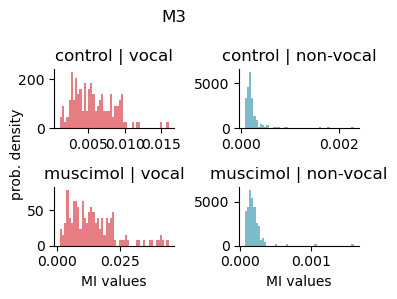

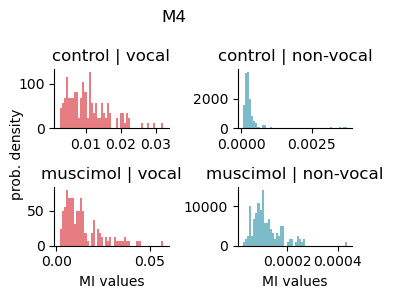

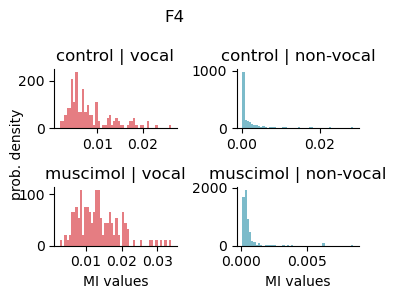

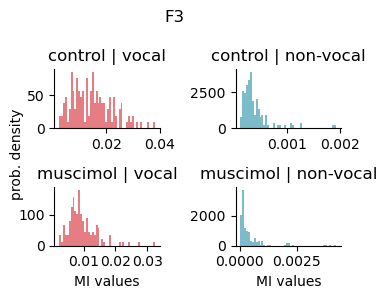

In [375]:
for a, anim in enumerate(data.keys()):
    fig, axes = plt.subplots(2,2, figsize=(4,3))#, sharex=True)
    for i, treat in enumerate(treats):
        for j, period in enumerate(voc_periods):
            axes[i,j].hist(np.concatenate(MI_matrix[treat][period][a]), density=True, bins=50, color=voc_map[period], alpha=0.7 )
            axes[i,j].set_title(f'{treat} | {period}')
            _despine(axes[i,j])
            axes[-1,j].set_xlabel('MI values')
            # axes[i,0].set_ylabel('prob. density')
    fig.supylabel('prob. density', fontsize=10, x=0.09)
    fig.suptitle(f'{anim}')
    fig.tight_layout()
    # fig.subplots_adjust(wspace=0.25, top=0.8)


In [351]:
stds = {(treat, period): np.array([np.std(m) for m in MI_matrix[treat][period]]) for treat in MI_matrix for period in MI_matrix[treat]}
phase_at_peakMI = [phase_centers[np.where(m==np.max(m))[0]][0] for m in MI_matrix[treat][period] for treat in MI_matrix for period in MI_matrix[treat]]
amp_at_peakMI = [amp_centers[np.where(m==np.max(m))[1]][0] for m in MI_matrix[treat][period] for treat in MI_matrix for period in MI_matrix[treat]]
MI_at_peakMI = [np.max(m) for m in MI_matrix[treat][period] for treat in MI_matrix for period in MI_matrix[treat]]

df = pd.DataFrame([
    {'treat': treat, 'period': period, 'std': s}
    for (treat, period), arr in stds.items()
    for s in arr
])
df['phase_at_peakMI'] = phase_at_peakMI
df['amp_at_peakMI'] = amp_at_peakMI
df['MI_at_peakMI'] = MI_at_peakMI

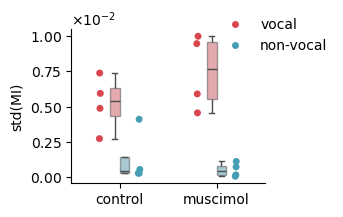

In [354]:
fig, ax = plt.subplots(figsize=(2.5,2))
sns.stripplot(df, x='treat', y='std', 
              hue='period', palette=voc_map, 
              dodge=True, jitter=0.02, 
              ax=ax)
sns.boxplot(df, x='treat', y='std',
                hue='period', palette=voc_map,
                dodge=True, width=0.2,
                fliersize=0,
                legend=False,
                ax=ax)
for patch in ax.patches:
    patch.set_alpha(0.5)
ax.set_xlabel('')
fmt = ticker.ScalarFormatter(useMathText=True)
fmt.set_powerlimits((0, 0))
ax.yaxis.set_major_formatter(fmt)
ax.set_ylabel('std(MI)')
ax.legend_.remove()
fig.legend(loc='upper right', bbox_to_anchor=(1.2, 1), frameon=False)
_despine(ax)
for ext in ['png','pdf']:
    fig.savefig(results_dir+'/_stdMI_vocaltreat.'+ext, 
                bbox_inches='tight', transparent=True, dpi=500)

